In [90]:
import numpy as np
#Implmentation function of jacobi
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors =[]
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        # calculate error
        error_i = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error_i)
        #check for convergence
        if error_i < tol:
            return x_new, k+1, errors
        x = x_new
        
    return x, max_iterations,errors

In [91]:
#Implmentation function of gauss_seidel
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors =[]
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        # calculate error
        error_i = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error_i)
        #check for convergence
        if error_i < tol:
            return x_new, k+1, errors
        x = x_new
    return x, max_iterations,errors

In [92]:
#my system of equations Ax = b kinda thing
A = np.array([[3.,-0.1,-0.2],[0.1,7.,-0.3],[0.3,-0.2,10.]])
b = np.array([7.85,-19.3,71.4])
x0 = np.zeros_like(b)
tol = [1e-3,1e-6,1e-9]
max_iterations = 100

In [93]:
result = {}
solution_j = {}
solution_gs = {}
iterations_j = {}
iterations_gs = {}
error_j = {}
error_gs = {}
for i in range (0,3):
    #Solve using jacobi
    solution_j[i], iterations_j[i], error_j[i] = jacobi(A, b, x0, tol[i], max_iterations)
    
    #solve using gauss_seidel
    solution_gs[i], iterations_gs[i], error_gs[i]= gauss_seidel(A, b, x0, tol[i], max_iterations)
    
#comparison in interations of jacobi to gauss seidel across different tolerances
for g in range(0,3):
    print(f"tolerance: {tol[g]}")
    print(f"number of interations in jacobi method: {iterations_j[g]}")
    print(f"number of interations in gauss seidel method: {iterations_gs[g]}")
    print()
#gauss seidel accross the board uses less iterations

tolerance: 0.001
number of interations in jacobi method: 4
number of interations in gauss seidel method: 4

tolerance: 1e-06
number of interations in jacobi method: 7
number of interations in gauss seidel method: 5

tolerance: 1e-09
number of interations in jacobi method: 9
number of interations in gauss seidel method: 7



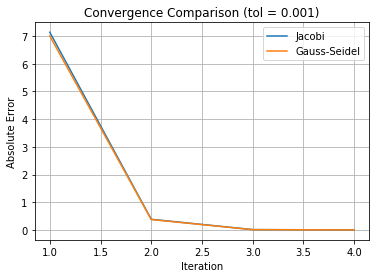

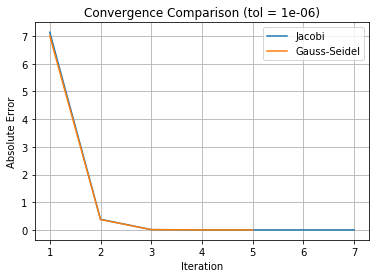

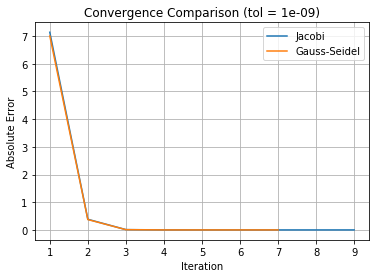

In [94]:
#graphing
for j in range(0,3):

    plt.figure()
#     plt.yscale("log")
    plt.plot(range(1, len(error_j[j]) + 1), error_j[j], label="Jacobi")
    plt.plot(range(1, len(error_gs[j]) + 1), error_gs[j], label="Gauss-Seidel")

    plt.xlabel("Iteration")
    plt.ylabel("Absolute Error")
    plt.title(f"Convergence Comparison (tol = {tol[j]})")
    plt.legend()
    plt.grid()

plt.show()

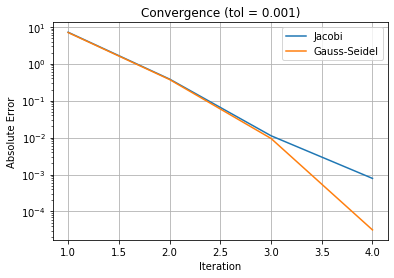

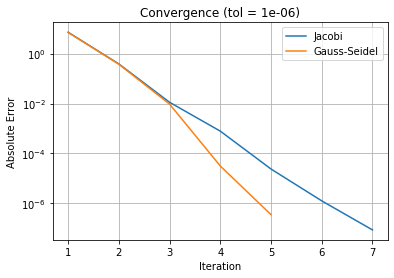

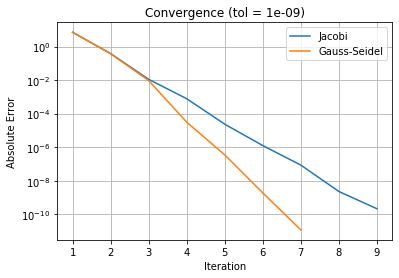

In [96]:
#Log scale makes it a bit easier to see the difference in number of iterations needed as well as their difference in error. 
#had to look up there was no difference in error between the two
import matplotlib.pyplot as plt

for j in range(0,3):

    plt.figure()

    plt.plot(range(1, len(error_j[j]) + 1),
             error_j[j],
             label="Jacobi")

    plt.plot(range(1, len(error_gs[j]) + 1),
             error_gs[j],
             label="Gauss-Seidel")
    plt.yscale("log")

    plt.xlabel("Iteration")
    plt.ylabel("Absolute Error")
    plt.title(f"Convergence (tol = {tol[j]})")
    plt.legend()
    plt.grid()

plt.show()

At higher tolerances, more iterations are needed to provide an acurate result towards convergence. With gauss seidel out-performing jacobi in accurancy and number of iterations each time. 